In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

# Model
- no batch norm at the end of a model
- tanh in the gen
- besides the first projection layer, both have the same size

In [ ]:
latent_dim = 100

class MinibatchDiscrimination(layers.Layer):
    def __init__(self, num_kernels=50, kernel_dim=3, **kwargs):
        super(MinibatchDiscrimination, self).__init__(**kwargs)
        self.num_kernels = num_kernels
        self.kernel_dim = kernel_dim

    def build(self, input_shape):
        self.T = self.add_weight(
            name='kernel',
            shape=(input_shape[1], self.num_kernels, self.kernel_dim),
            initializer='glorot_uniform',
            trainable=True
        )
        super(MinibatchDiscrimination, self).build(input_shape)

    def call(self, x):
        activation = tf.tensordot(x, self.T, axes=[[1], [0]])
        abs_diffs = tf.abs(tf.expand_dims(activation, 3) - tf.expand_dims(tf.transpose(activation, [1, 2, 0]), 0))
        abs_diffs = tf.reduce_sum(abs_diffs, axis=2)
        minibatch_features = tf.reduce_sum(tf.exp(-abs_diffs), axis=2)
        return tf.concat([x, minibatch_features], axis=1)


generator = tf.keras.Sequential([

    keras.layers.Input(shape=(latent_dim,)),
    keras.layers.Dense(6 * 6 * 512),
    keras.layers.BatchNormalization(),
    keras.layers.ReLU(),

    keras.layers.Reshape([6,6,512]),
    keras.layers.Conv2DTranspose(512, kernel_size=4, strides=2,padding = 'same'),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(0.2),


    keras.layers.Conv2DTranspose(256, kernel_size=4, strides=2,padding = 'same'),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(0.2),

    keras.layers.Conv2DTranspose(128, kernel_size=4, strides=2,padding = 'same'),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(0.2),

    keras.layers.Conv2DTranspose(64, kernel_size=4, strides=2,padding = 'same'),
    keras.layers.BatchNormalization(),
    keras.layers.LeakyReLU(0.2),


    keras.layers.Conv2DTranspose(3, kernel_size=4, padding ='same', activation='tanh'),
    #never put batch norm here

], name = "gen")

discriminator = tf.keras.Sequential([
    keras.layers.Input(shape=(96,96,3)),

    keras.layers.Conv2D(64, kernel_size=4,strides =2,padding='same'),
    keras.layers.LeakyReLU(0.2),
    keras.layers.Dropout(0.4),

    keras.layers.Conv2D(128, kernel_size=4, strides=2, padding='same'),
    keras.layers.LeakyReLU(0.2),
    keras.layers.Dropout(0.4),

    keras.layers.Conv2D(256, kernel_size=4, strides=2, padding='same'),
    keras.layers.LeakyReLU(0.2),
    keras.layers.Dropout(0.4),

    keras.layers.Conv2D(512, kernel_size=4, strides=2, padding='same'),
    keras.layers.LeakyReLU(0.2),
    keras.layers.Dropout(0.4),

    keras.layers.Flatten(),
    MinibatchDiscrimination(num_kernels=50, kernel_dim=5),
    keras.layers.Dense(1, activation='sigmoid')

], name = "disc")


opt_gen = keras.optimizers.Adam(2e-5,beta_1=0.5)
opt_disc = keras.optimizers.Adam(2e-5,beta_1=0.5)
loss_fn = keras.losses.BinaryCrossentropy()

In [14]:
generator.summary()
discriminator.summary()

Model: "gen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 18432)          │     1,861,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 18432)          │        73,728 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 12, 12, 512)    │     4,194,816 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 24, 24, 256)    │     2,097,408 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 48, 48, 128)    │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 48, 48, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 48, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 96, 96, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 96, 96, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 96, 96, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 96, 96, 3)      │         3,075 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,890,051 (33.91 MB)

 Trainable params: 8,851,267 (33.76 MB)

 Non-trainable params: 38,784 (151.50 KB)

Model: "disc"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 256)    │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 512)      │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ minibatch_discrimination_1      │ (None, 18482)          │     4,608,000 │
│ (MinibatchDiscrimination)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │        18,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,383,027 (28.16 MB)

 Trainable params: 7,383,027 (28.16 MB)

 Non-trainable params: 0 (0.00 B)

# Dataset

In [ ]:

dataset_path = './house_plant_species_processed_96'
path = './gan_checkpoints'
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

imgs = []
for root, _, files in tqdm(os.walk(dataset_path)):
    for f in files:
        dataset_path = os.path.join(root, f)
        img = load_img(dataset_path, target_size=(96,96,3))
        img = (img_to_array(img) - 127.5) / 127.5
        imgs.append(img)

imgs = np.array(imgs, dtype='float32')

# Augmenting
data_augmentation = tf.keras.Sequential([
    keras.layers.RandomRotation(
        factor=0.05,              
        fill_mode="reflect",       
        fill_value=0.0,             
        interpolation="bilinear"    
    ),
    keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.1,
        fill_mode="reflect",       
        fill_value=0.0
    ),
    keras.layers.RandomZoom(
        height_factor=0.05,
        fill_mode="reflect",
        fill_value=0.0
    ),
    keras.layers.RandomFlip("horizontal"),
])

def augment_layer(images):
    return data_augmentation(images)

batch_size = 128
dataset = tf.data.Dataset.from_tensor_slices(imgs).shuffle(1000)
dataset = dataset.batch(batch_size, drop_remainder=True).prefetch(1)

augmented_dataset = dataset.map(augment_layer, num_parallel_calls=tf.data.AUTOTUNE)
augmented_dataset = augmented_dataset.prefetch(tf.data.AUTOTUNE)




In [ ]:
path = './weights_gen/'

ckpointsGen = tf.train.Checkpoint(step=tf.Variable(1), optimizer=opt_gen, net=generator)
ckpointsDisc = tf.train.Checkpoint(step=tf.Variable(1), optimizer=opt_disc, net=discriminator)
managerGen = tf.train.CheckpointManager(ckpointsGen, path, max_to_keep=1)
managerDisc = tf.train.CheckpointManager(ckpointsDisc, os.path.join(path,'disc'), max_to_keep=1)

ckpointsGen.restore(managerGen.latest_checkpoint)
if managerGen.latest_checkpoint:
  print("Restored from {}".format(managerGen.latest_checkpoint))
else:
  print("Initializing from scratch.")

ckpointsDisc.restore(managerDisc.latest_checkpoint)
if managerDisc.latest_checkpoint:
  print("Restored from {}".format(managerDisc.latest_checkpoint))
else:
  print("Initializing from scratch.")

files['ckpt-51.data-00000-of-00001', 'checkpoint', 'ckpt-51.index']
Restored from /home/aurel/Code/ML-DL/GAN/Deep-Convolutional-GAN---houseplants/weights_gen/ckpt-51
Initializing from scratch.


'for images in augmented_dataset.take(1):\n    img = images.numpy()\n    plt.figure(figsize=(10, 10))\n    for i in range(9):\n        ax = plt.subplot(3, 3, i + 1)\n        img[i] = (img[i]+1 )/2\n        plt.imshow(img[i].squeeze(), cmap=\'binary\')\n        plt.axis("off")\n    plt.show()'

In [ ]:
def generate_example(name):
  noise = tf.random.normal(shape=[28, latent_dim])
  gen_images = generator(noise)
  gen_images = (gen_images + 1) /2
  fig, ax = plt.subplots(nrows=4, ncols=7, figsize=(18, 10)) 
  for i in range(4):
      for j in range(7):
          index = i * 7 + j
          if index < len(gen_images): 
              ax[i, j].imshow(gen_images[index])
              ax[i, j].axis('off') 
  plt.savefig(f'{path}/images/{str(name)}.jpg')
  plt.close(fig)


# Training

In [ ]:
import random

class ReplayBuffer:
    def __init__(self, capacity=50):
        self.capacity = capacity
        self.buffer = []

    def call(self, current_batch):
        return_batch = []

        for image in current_batch:
            image = np.expand_dims(image, axis=0)

            if len(self.buffer) < self.capacity:
                self.buffer.append(image)
                return_batch.append(image)
            else:
                if random.random() > 0.5:
                    return_batch.append(image)
                else:
                    random_id = random.randint(0, self.capacity - 1)
                    old_image = self.buffer[random_id]

                    self.buffer[random_id] = image

                    return_batch.append(old_image)

        return np.concatenate(return_batch, axis=0)

replay_buffer = ReplayBuffer(capacity=50) 
accuracy_disc = tf.keras.metrics.BinaryAccuracy()
accuracy_gen = tf.keras.metrics.BinaryAccuracy()

@tf.function
def train_step(X_batch, gen_training_nbr=5):
    batch_size=tf.shape(X_batch)[0]
    noise = tf.random.normal(shape=[batch_size, latent_dim])
    fake = generator(noise)
    mixed_fakes = tf.py_function(func=replay_buffer.call, inp=[fake], Tout=tf.float32)
    mixed_fakes.set_shape(fake.shape)
    #disc training
    with tf.GradientTape() as disc_tape:

        disc_res_xbatch = discriminator(X_batch)
        disc_res_mixed_fakes = discriminator(mixed_fakes)
        loss_disc_Xbatch = loss_fn(tf.ones((batch_size,1)), disc_res_xbatch) #label smoothing *0.9
        loss_disc_fake = loss_fn(tf.zeros((batch_size,1)), disc_res_mixed_fakes) #mixed fake if replay buffer enabled
        loss_disc = (loss_disc_Xbatch + loss_disc_fake)/2

    accuracy_disc.update_state(tf.zeros((batch_size,1)),disc_res_mixed_fakes)


    grads = disc_tape.gradient(loss_disc, discriminator.trainable_weights)
    opt_disc.apply_gradients(zip(grads, discriminator.trainable_weights))

    #gen training
    gen_losses = []
    for _ in range(gen_training_nbr):
      with tf.GradientTape() as gen_tape:
          noise_gen = tf.random.normal(shape=[batch_size, latent_dim])
          output = discriminator(generator(noise_gen))
          loss_gen = loss_fn(tf.ones((batch_size,1)), output)
          gen_losses.append(loss_gen)

          accuracy_gen.update_state(tf.ones((batch_size,1)), output)

      grads = gen_tape.gradient(loss_gen, generator.trainable_weights)
      opt_gen.apply_gradients(zip(grads, generator.trainable_weights))
    return (loss_disc,tf.reduce_mean(gen_losses))

hist_gen = []
hist_disc = []


In [ ]:
acc_list = []
acc_list2 = []

cur_epoch = 0
for epoch in range(cur_epoch,cur_epoch+100):
    accuracy_disc.reset_state()
    accuracy_gen.reset_state()
    for X_batch in tqdm(augmented_dataset):
        d,g = train_step(X_batch)
    acc_list.append(accuracy_gen.result())
    acc_list2.append(accuracy_disc.result())
    hist_gen.append(tf.reduce_mean(g))
    hist_disc.append(tf.reduce_mean(d))
    print(f'epoch : {epoch}, gen_loss :{hist_gen[-1]:.2f}, disc_loss :{hist_disc[-1]:.2f} ')
    print((f'accuracies, gen : {accuracy_gen.result():.2f}, disc : {accuracy_disc.result():.2f}'))

    if epoch % 5 == 0:
      managerGen.save()
      managerDisc.save()
    generate_example(f'_{epoch}')
    cur_epoch+=1


In [ ]:
plt.ylim(0,5)
plt.plot(hist_disc,'g', label='disc')
plt.plot(hist_gen,'r', label='gen')
plt.legend()
plt.show()


In [ ]:
plt.ylim(0,1)
plt.plot(acc_list2,'g', label='disc')
plt.plot(acc_list,'r', label='gen')
plt.legend()
plt.show()

# Results
trained on ~xxx epochs (xxx batches * 32 examples)

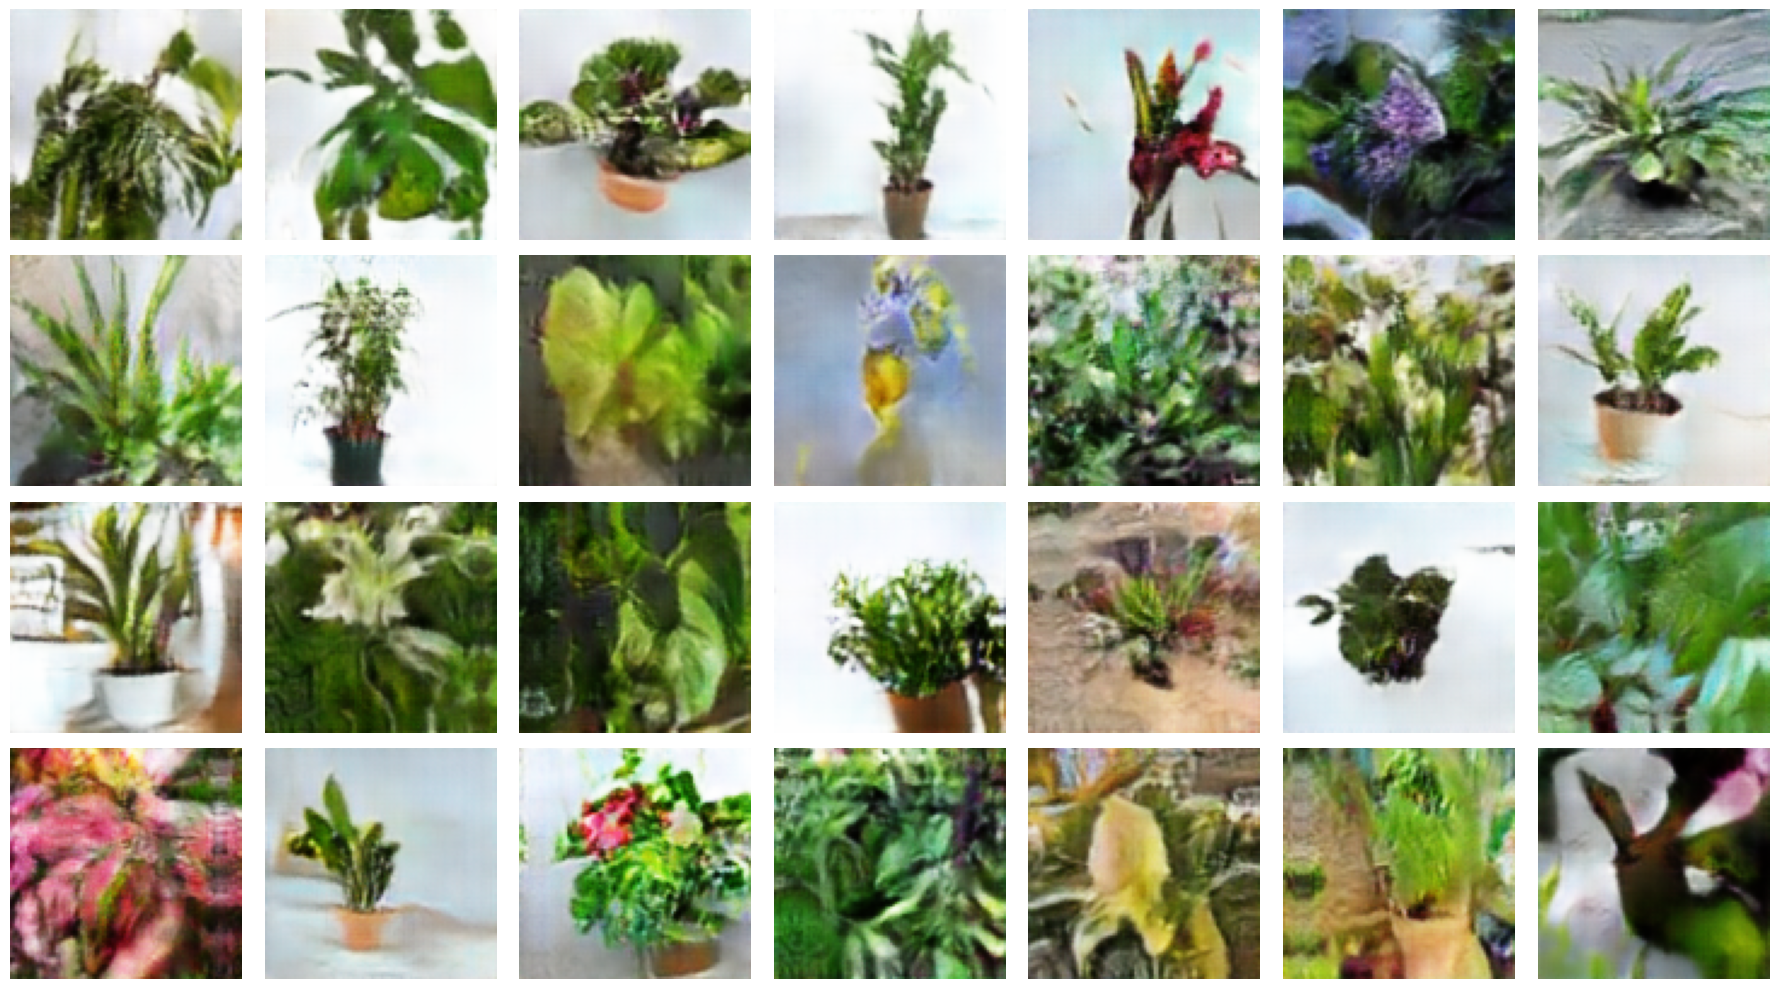

In [ ]:
noise = tf.random.normal(shape=[28, latent_dim])
gen_images = generator(noise)
gen_images = (gen_images + 1) /2
fig, ax = plt.subplots(nrows=4, ncols=7, figsize=(18, 10)) 
for i in range(4):
    for j in range(7):
        index = i * 7 + j
        if index < len(gen_images): 
            ax[i, j].imshow(gen_images[index])
            ax[i, j].axis('off') 
plt.tight_layout() 
plt.show()

In [ ]:
M = tf.random.normal(shape=[1, latent_dim])
c=0
for j in tqdm(range(15)):
  B = tf.random.normal(shape=[1, latent_dim])
  _lambda = 0.01
  n = 100 # a pas changer
  v = B * _lambda
  # print(tf.norm(M, ord=1).numpy())

  for i in range(100):
      M = M + v
      M = M / tf.norm(M, ord=1).numpy() * n
      # print(tf.norm(M, ord=1).numpy())
      img = tf.reshape(generator(M),[96,96,3])
      img = (img +1 )/2
      plt.imsave(f'./{c}.png',img, cmap='binary') # wrong path
      c+=1

!ffmpeg -y -framerate 60 -i ../Frames/%d.png ../out2.mp4
